# EDA Lab - Step 1

Dataset: **UCI Adult Income** (from Awesome Public Datasets / UCI ML Repository).

Goal in this step:
- Load the dataset
- Verify row/column requirements
- Verify at least 5 numerical columns
- Keep Seaborn ready for all plots

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn theme for consistent visuals in later steps
sns.set_theme(style="whitegrid")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
    "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
    "hours_per_week", "native_country", "income"
]

df = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True)

numeric_cols = df.select_dtypes(include="number").columns.tolist()

print("Rows, Columns:", df.shape)
print("\nNumeric columns:", numeric_cols)
print("Count of numeric columns:", len(numeric_cols))
print("\nFirst 5 rows:")
print(df.head())

Rows, Columns: (32561, 15)

Numeric columns: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Count of numeric columns: 6

First 5 rows:
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capita

## Step 2 (Concise)

Univariate EDA with Seaborn:
- Numeric columns: histogram + min/max/mean/median + IQR outlier count
- Categorical columns: bar chart + category count summary + outlier categories by frequency

age: min=17, max=90, mean=38.58, median=37.00, outliers=143


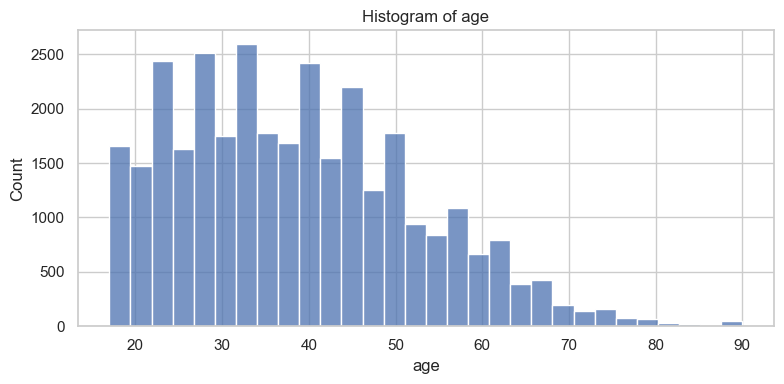

fnlwgt: min=12285, max=1484705, mean=189778.37, median=178356.00, outliers=992


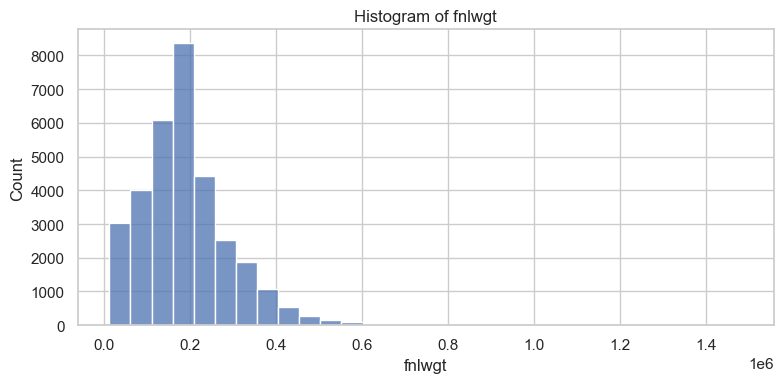

education_num: min=1, max=16, mean=10.08, median=10.00, outliers=1198


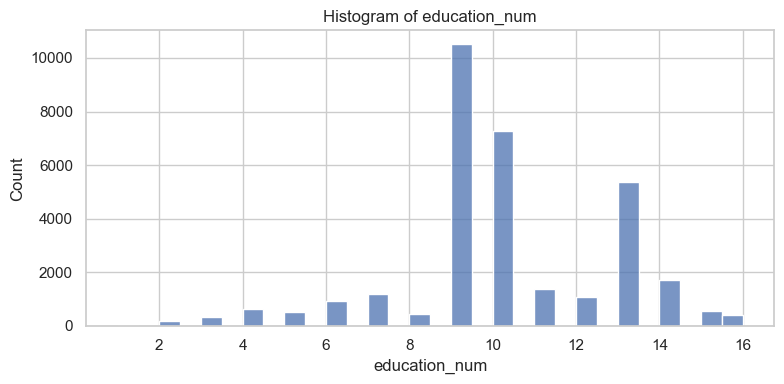

capital_gain: min=0, max=99999, mean=1077.65, median=0.00, outliers=2712


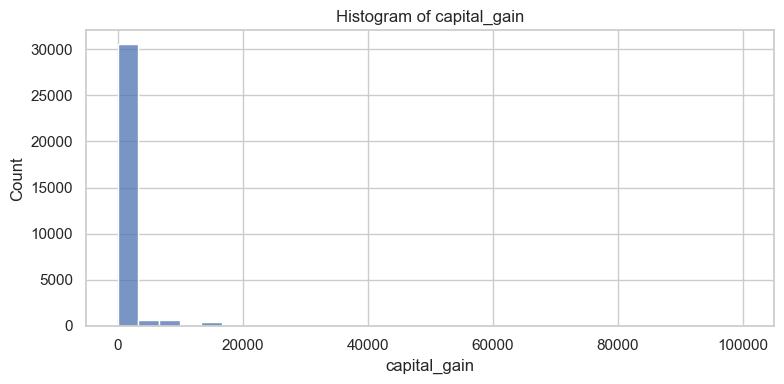

capital_loss: min=0, max=4356, mean=87.30, median=0.00, outliers=1519


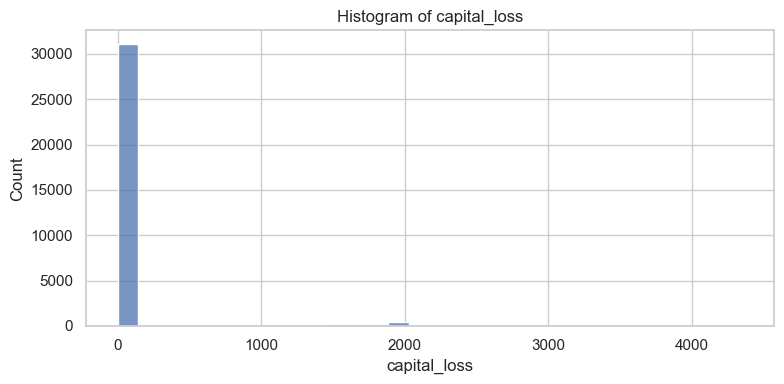

hours_per_week: min=1, max=99, mean=40.44, median=40.00, outliers=9008


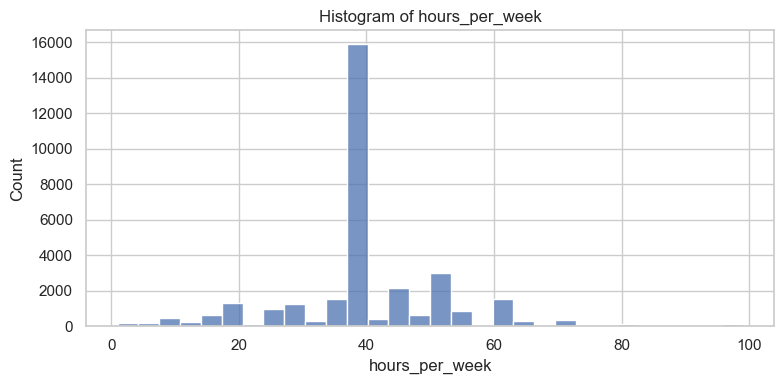

workclass: count_min=7, count_max=22696, count_mean=3617.89, count_median=1298.00, flagged=['Private']


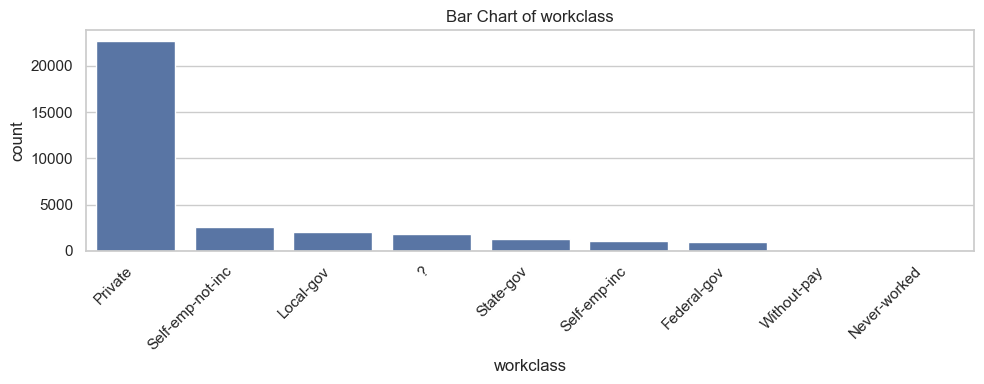

education: count_min=51, count_max=10501, count_mean=2035.06, count_median=789.50, flagged=['HS-grad', 'Some-college', 'Bachelors']


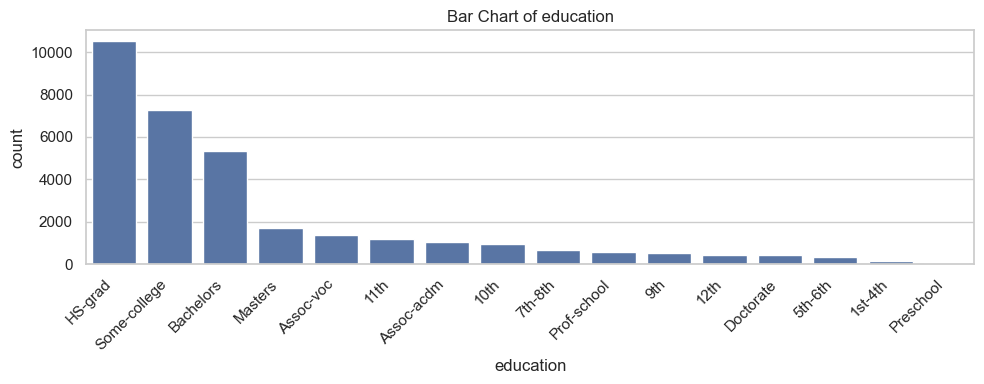

marital_status: count_min=23, count_max=14976, count_mean=4651.57, count_median=1025.00, flagged=[]


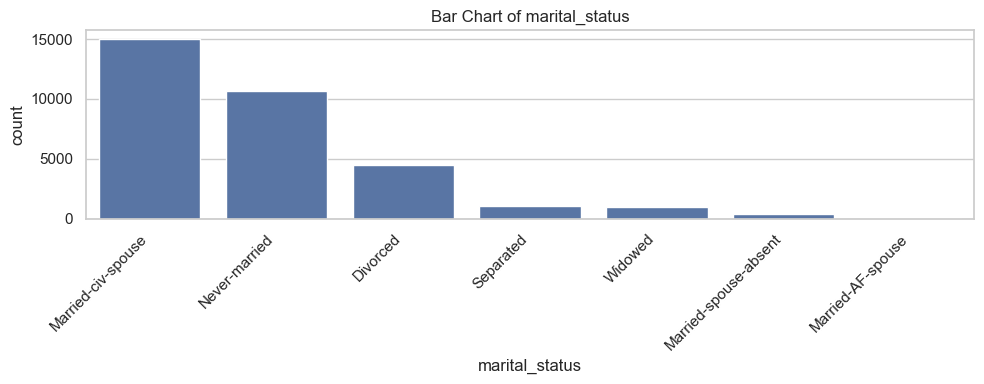

occupation: count_min=9, count_max=4140, count_mean=2170.73, count_median=1843.00, flagged=[]


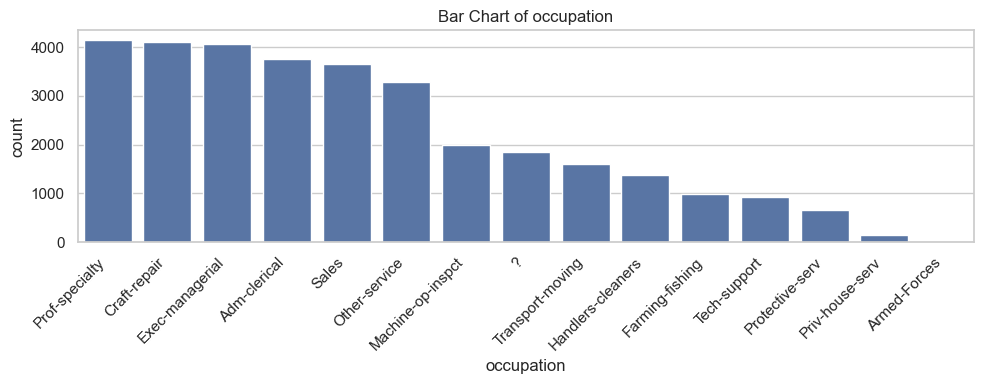

relationship: count_min=981, count_max=13193, count_mean=5426.83, count_median=4257.00, flagged=[]


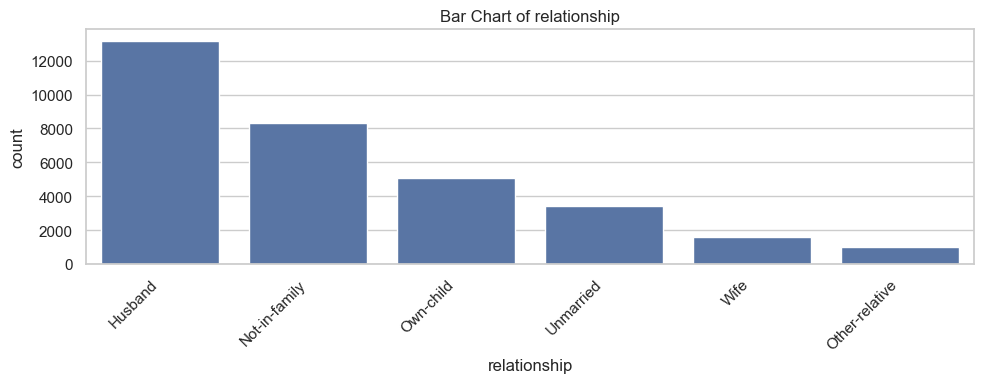

race: count_min=271, count_max=27816, count_mean=6512.20, count_median=1039.00, flagged=['White']


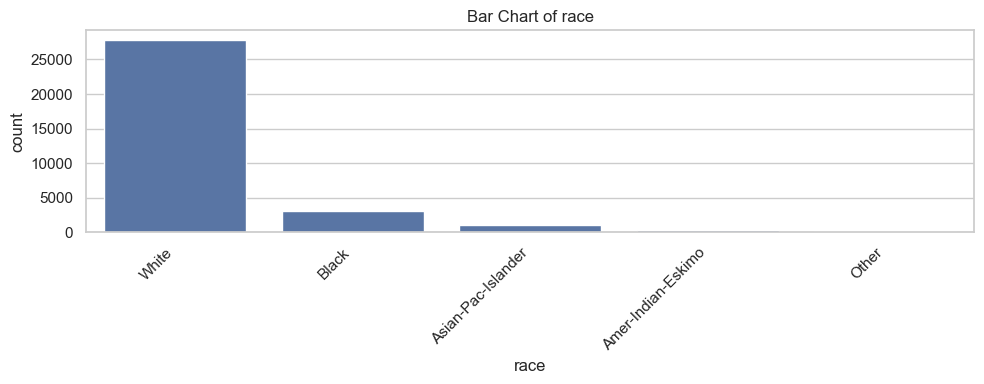

sex: count_min=10771, count_max=21790, count_mean=16280.50, count_median=16280.50, flagged=[]


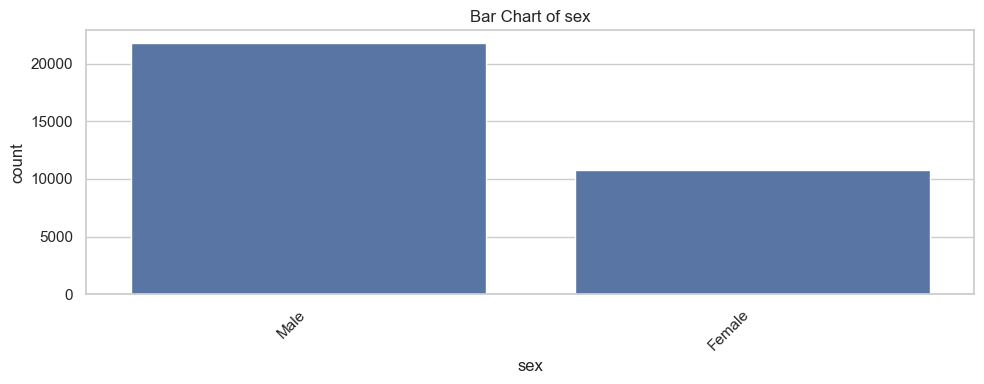

native_country: count_min=1, count_max=29170, count_mean=775.26, count_median=55.00, flagged=['United-States', 'Mexico', '?', 'Philippines']


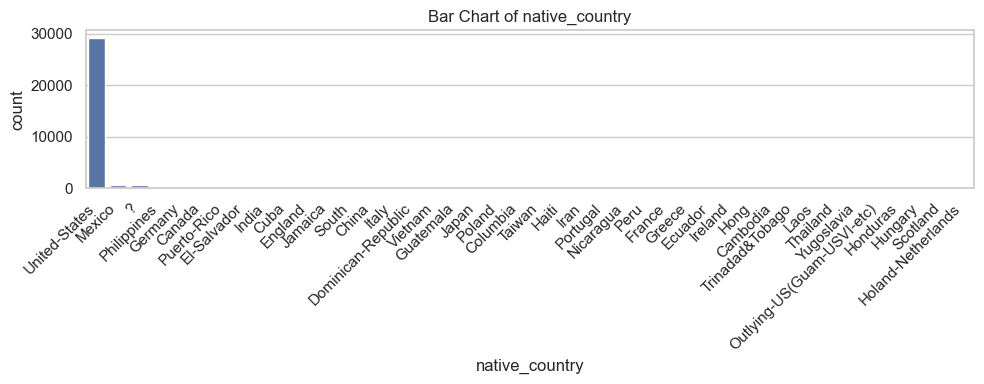

income: count_min=7841, count_max=24720, count_mean=16280.50, count_median=16280.50, flagged=[]


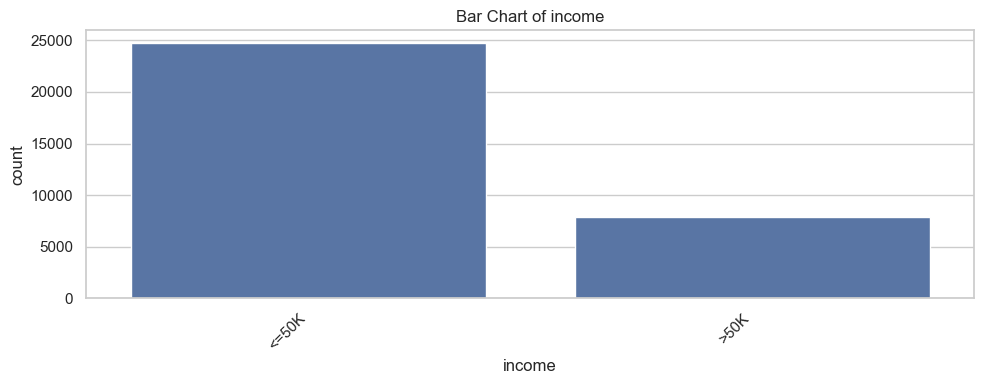

In [15]:
# Concise univariate EDA (Seaborn)
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]

# Numeric: required stats + histogram
for c in numeric_cols:
    x = df[c].dropna()
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    outliers = ((x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)).sum()

    print(f"{c}: min={x.min()}, max={x.max()}, mean={x.mean():.2f}, median={x.median():.2f}, outliers={int(outliers)}")

    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=c, bins=30)
    plt.title(f"Histogram of {c}")
    plt.tight_layout()
    plt.show()

# Categorical: frequency stats + bar chart
for c in categorical_cols:
    vc = df[c].astype(str).value_counts(dropna=False)
    q1, q3 = vc.quantile(0.25), vc.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flagged = vc[(vc < low) | (vc > high)].index.tolist()

    print(f"{c}: count_min={int(vc.min())}, count_max={int(vc.max())}, count_mean={vc.mean():.2f}, count_median={vc.median():.2f}, flagged={flagged}")

    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=c, order=vc.index)
    plt.title(f"Bar Chart of {c}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()